# 🚲 Neural Networks as Universal Approximators: Rebuilding VeloZüri's Demand Map

## The situation

You have just taken over as **Head of City Operations at VeloZüri**, the bike-sharing
operator that runs 12,000 bikes across 380 docks in Zürich. Two decisions are sitting on
your desk this week, and both of them are really the same decision in disguise.

**First**, the rebalancing vans. Every night a fleet of vans redistributes bikes so that
each dock starts the morning with roughly what it will need. Right now the schedule is a
spreadsheet somebody built in 2019 out of round numbers. Your operations lead, Nadia,
wants to know: *how many bikes should the Hauptbahnhof dock hold at each hour of the day?*

**Second**, three new depots. The capital budget has been approved for three storage
depots, and once the concrete is poured they stay where you put them for fifteen years.
*Where in the city is demand actually concentrated?*

Nobody can hand you a formula for either. Demand is not a straight line, it is not a
bell curve, and it is not anything with a name. It is just a **shape**, one you can
see in the data and cannot write down.

This notebook is about the one property of neural networks that makes them the right tool
for exactly this situation: given enough neurons, a network can reproduce **any**
continuous shape, without you ever having to say what the shape is. That property has a
name, *universal approximation*, and by the end of Part 2 you will have built one by
hand, on paper-simple arithmetic, before you train anything.

Everything here runs on **NumPy alone**. No PyTorch, no TensorFlow, no GPU. A neural
network is a small amount of arithmetic, and it helps to see that for yourself once.

### What is ahead

1. **One neuron.** The smallest thing a network can do, and why it is not enough.
2. **Three ramps.** Stack three straight lines and you get a bump, and bumps make anything.
   You will hand-build the demand curve with 19 numbers.
3. **Training.** Hand-tuning 19 numbers does not scale to 380 docks. Gradient descent
   does. How many neurons do you actually need to buy?
4. **The whole city.** The same idea with two inputs instead of one, turning a scatter
   of surveyed sites into a demand map, and the map into three depot locations.
5. **The limits.** Where "universal" quietly stops being true, and what that costs you
   on a Tuesday night.

In [1]:
#@title ⚙️ Setup: the NumPy engine, the display layer and the house style { display-mode: "form" }
# Three readable files do all the work in this notebook, and all three live in the course
# repo next to it:
#   universal_approximation_utils.py : TinyMLP (forward pass, backpropagation and Adam in
#                                      plain NumPy), the VeloZüri data, analysis helpers
#   universal_approximation_ui.py    : every figure, explainer and interactive panel
#   universal_approximation_setup.py : installs anything missing, imports the other two
#                                      into this notebook, applies the house style
# `_FILES` below is a gzipped copy of all three, embedded so that this notebook also runs
# for a student with no course-repo access and no network. Edit the files; never the blob.
# build_notebooks.py re-embeds them on every build.
_FILES = "..."
exec(__import__('json').loads(__import__('zlib').decompress(
    __import__('base64').b64decode(_FILES)))['universal_approximation_setup.py'])

✅ Setup complete · NumPy 2.1.3 · RANDOM_STATE = 42 · no deep-learning framework in sight.


In [2]:
#@title 🗺️ Roadmap: the five moves in this notebook (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_roadmap()

---

## The data

Two logs, both from VeloZüri's own systems.

**The dock log.** Every half hour between 05:00 and 23:00, for forty days, a counter at
the Hauptbahnhof dock records how many bikes were taken out. That gives us a cloud of
`(hour, pickups)` observations: the same hour appears forty times, with a different count
each time, because a Tuesday in drizzle is not a Thursday in sunshine.

**The site survey.** Last year the expansion team scored 700 candidate locations across
a 12 km × 12 km box centred on the Hauptbahnhof, recording daily pickups at each. That
gives us `(x, y, pickups)`, a scatter of dots on a map, not a map.

We also carry a third file, `truth`, that no real operator ever has: a **full census** of
demand at every point in the city. It exists here only so we can grade ourselves honestly
in Part 4. Never let it into a model.

In [3]:
#@title 📥 Data loading: the VeloZüri logs { display-mode: "form" }
# Tries, in order: a local data/ folder, the copy published in the public course repo
# (no credentials needed, and the path this notebook normally takes), a clone of the
# private course repo with a GitHub token for instructors, and finally a seeded offline
# rebuild that reproduces the committed CSVs exactly. You never get stuck.
hourly, stations, truth = load_velozueri_data()
describe_datasets(hourly, stations, truth)

✅ Loaded the VeloZüri data from the public course repo.

Dock log      : 1,480 half-hourly counts over 40 days at the Hauptbahnhof
Site survey   : 700 surveyed locations across the city
Full census   : 10,000 map cells (the study we could never afford)


,day,hour,pickups
0,1,5.0,0
1,1,5.5,5
2,1,6.0,4
3,1,6.5,34
4,1,7.0,78


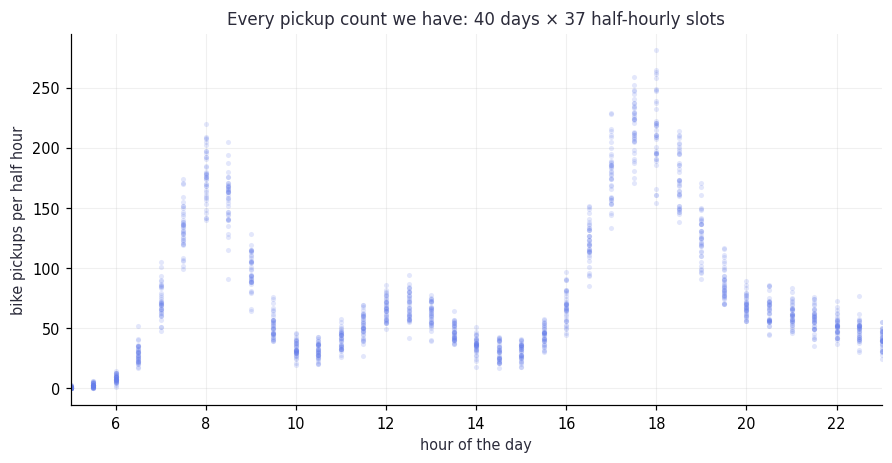

In [13]:
#@title 📊 Forty days at the Hauptbahnhof dock (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_demand_scatter(hourly)

There is the shape. A quiet dawn, a hard commuter spike just after 08:00, a modest lunch
lift, a taller spike at 17:45 when the offices empty, and a long evening drift.

Nobody designed that curve. It is the aggregate of forty thousand individual decisions
about how to get to work. And Nadia needs a number for each hour.

Notice how much of the vertical spread at any given hour is just *noise*: the same 08:00
slot ranges from about 140 to 210 across the forty days. No model, however clever, can
predict which of those forty Tuesdays tomorrow will be. Keep that in mind: it puts a hard
floor under how good any forecast can get, and we will measure that floor in Part 3.

## Part 1. One neuron: what is the smallest thing a network can do?

Before asking what an entire neural network can do, it helps to understand what a single neuron does. On its own, a neuron is surprisingly simple.

It receives one number as input, in this case the hour of the day. It multiplies that number by a **weight**, adds a **bias**, and then passes the result through an activation function. Here we use ReLU, one of the most common activation functions in neural networks:

$$
\text{ReLU}(w\,h+b)=\max(0,\;w\,h+b)
$$

where $h$ is the hour, $w$ is the weight, and $b$ is the bias. Despite its name, *rectified linear unit*, ReLU is very simple: if the input is negative, the output is zero; if the input is positive, the output is left unchanged.

To understand what this means geometrically, consider the point at which the neuron stops returning zero. This happens when

$$
w\,h+b=0,
$$

so

$$
h=-\frac{b}{w}.
$$

This value tells us when the neuron begins to contribute. After that point, the output follows a straight line, changing by $w$ for every additional hour.

A single ReLU neuron therefore behaves like a **ramp**. Its output is zero up to a certain starting point, then it changes linearly. We can rewrite the same expression in a more intuitive form:

$$
\text{ramp}(h)
=
\text{slope}\times
\max\bigl(0,\;h-\text{start}\bigr),
$$

where

$$
\text{start}=-\frac{b}{w},
\qquad
\text{slope}=w.
$$

This form makes the two parameters easier to interpret. The **start** determines the hour at which the neuron begins to contribute, while the **slope** determines how quickly its contribution changes after that hour.

In plain language, a neuron is expressing a very simple rule: *"Contribute nothing until this hour. After that, change the predicted number of pickups by this amount for every additional hour."*

That is the basic contribution of one neuron in this model: a single linear ramp. The helper function `relu_ramp(hour, start, slope)` in the engine implements exactly this formula.


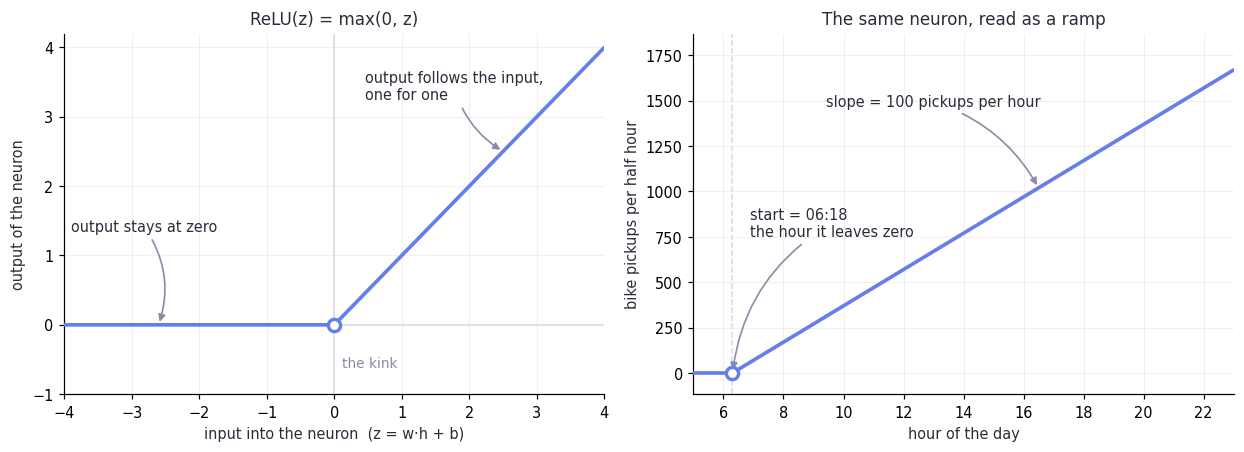

In [5]:
#@title 📊 The ReLU activation, and the same neuron as a ramp (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_relu_function()

In [6]:
#@title 📊 The two knobs on a single neuron (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_neuron_knobs()

### 🎯 Exercise 1. The morning ramp

Nadia's first question is the simplest one: **how does demand build up in the morning?**

Look again at the scatter above. Pickups are close to zero around 05:00, start rising at about 06:30, and by 08:00 they are close to 175 per half hour.

That is almost exactly the shape produced by a single ReLU neuron: zero up to a certain hour, followed by a straight linear increase.

So let us see how much of the morning pattern we can reproduce with **just one neuron**.

**Task.** Choose the two parameters of the neuron:

* `start`, the hour at which the neuron begins to contribute;
* `slope`, how many additional pickups the neuron contributes for each hour after that point.

Your neuron should:

* remain at zero until about **06:20**;
* increase by roughly **100 pickups per hour** after that point;
* reach approximately the observed morning demand by around **08:00**.

Then evaluate the neuron over `hour_grid` and store the result in `one_neuron`.

The model you are building is

$$
\text{one\_neuron}(h)
=
\text{slope}\cdot
\max\bigl(0,\;h-\text{start}\bigr).
$$

<details>

<summary>💡 <b>Hint 1</b></summary>

The ramp should leave zero at about **06:20**.

In decimal hours, a convenient approximation is

```python
START = 6.3
```

</details>

<details>

<summary>🔧 <b>Hint 2</b></summary>

The slope is the number of pickups added for every hour after the ramp starts.

The target is about **100 pickups per hour**, so use

```python
SLOPE = 100.0
```

Then evaluate the neuron with

```python
one_neuron = relu_ramp(hour_grid, start=START, slope=SLOPE)
```

</details>


In [7]:
# 🎯 YOUR TURN, Exercise 1: the smallest possible model, a single neuron.
#
# 💭 Think first: a ramp can only sit at zero and then climb. It has no way back down,
#    and nothing in it ever levels off. Real demand at the Hauptbahnhof peaks at 08:00
#    and falls back to about 32 pickups by 15:00. So before you run anything: what do
#    you expect this one neuron to be predicting at three in the afternoon, and at
#    eleven at night?
#
# 🎯 Implement: set the two knobs so the ramp leaves zero at about 06:20 and then climbs
#    by roughly 100 pickups an hour. Then evaluate it on `hour_grid` with
#    `relu_ramp(hour_grid, start=..., slope=...)` and store the curve in `one_neuron`.
hour_grid = np.linspace(5, 23, 400)   # a fine grid of hours, for drawing smooth curves


def relu_ramp(hour, start, slope):
  return slope * np.maximum(0, hour - start)

START = 6.3
SLOPE = 100.0

one_neuron = relu_ramp(hour_grid, start=START, slope=SLOPE)

morning = (hourly['hour'] <= 8.0)
print(f'Typical error over 05:00–08:00 : '
      f'{rmse(hourly.loc[morning, "pickups"], relu_ramp(hourly.loc[morning, "hour"], START, SLOPE)):.1f} pickups')
print(f'What it predicts at 15:00      : {relu_ramp(15.0, START, SLOPE):.0f} pickups')
print(f'What it predicts at 23:00      : {relu_ramp(23.0, START, SLOPE):.0f} pickups')

Typical error over 05:00–08:00 : 13.8 pickups
What it predicts at 15:00      : 870 pickups
What it predicts at 23:00      : 1670 pickups


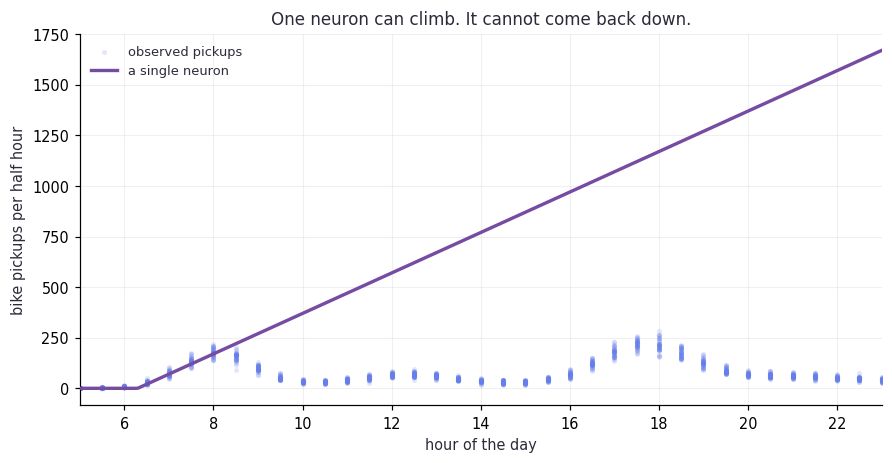

In [8]:
#@title 📊 One neuron against the whole day (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_single_neuron_fit(hourly, hour_grid, one_neuron)

### Reading the result

Across the morning build-up the single neuron is genuinely good: it tracks the climb to within about 14 pickups, which is not far off the best any model can do. And then it fails, completely and without limit. At 15:00 it predicts around 870 pickups when the true figure is only about 32, and by 23:00 the forecast has climbed to roughly 1,670. Send Nadia's vans out on that forecast and there are not enough bikes in Zürich to satisfy the model by dinner.

This is not a bug or a training failure. It is the *definition* of a ReLU neuron: one ramp, starting once and then continuing in a straight line. A neuron is a business rule with a threshold: **"from about 06:20, add another 100 pickups every hour"**. The problem is that one rule like this can describe the morning rise, but it cannot describe what happens later in the day.

The interesting question is what happens when you are allowed a second neuron.


## Part 2. Three ramps make a bump, and bumps make anything

Here is the key idea behind the whole notebook.

A single ReLU neuron makes only a **ramp**: zero up to a certain point, then a straight line. With three ramps, however, we can create a **bump**.

Let the first ramp start around **07:20** and rise. Let the second start around **08:06** with a negative slope strong enough to make the sum fall. Then let a third ramp start around **10:00** and cancel that fall. The result is

$$
0
\;\longrightarrow\;
\text{rise}
\;\longrightarrow\;
\text{fall}
\;\longrightarrow\;
0.
$$

So three ramps can create a local window of demand that starts, peaks, disappears, and leaves the rest of the day unchanged.

This is the step that leads to **universal approximation**. If we can place bumps at different locations, with different widths and heights, then we can add many of them together to trace a much more complicated curve.

A one hidden layer ReLU network computes

$$
f(h)
=
\sum_{j=1}^{n}
v_j\max(0,w_jh+b_j).
$$

Each hidden neuron contributes one ramp, while the output weight $v_j$ controls how strongly it contributes and with which sign. Positive weights add ramps, negative weights subtract them.

With enough neurons,

$$
\text{many ramps}
\;\longrightarrow\;
\text{many bumps}
\;\longrightarrow\;
\text{a flexible approximation}.
$$

Because every neuron contributes a straight ramp, the final ReLU network is always piecewise linear. Every change in slope comes from a neuron becoming active.


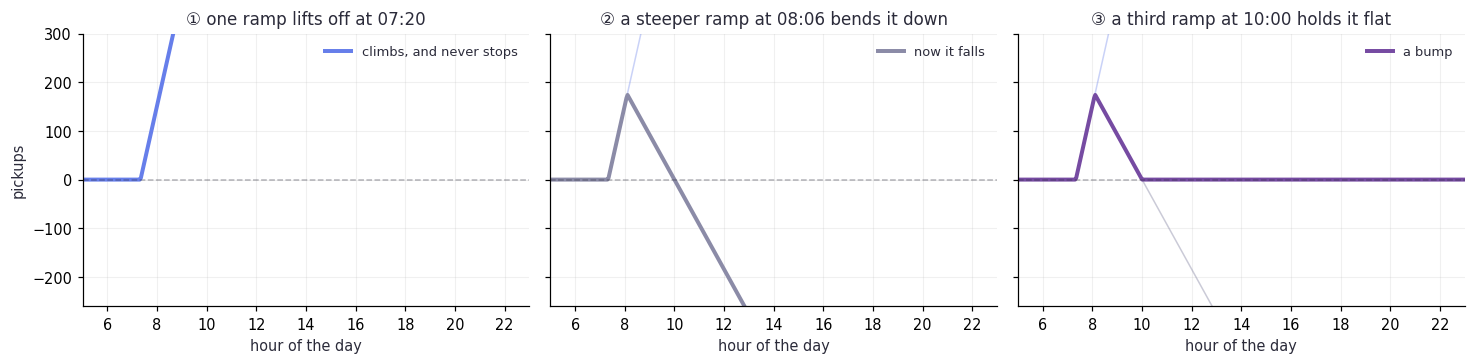

In [9]:
#@title 📊 Ramp + ramp + ramp = bump (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_bump_construction(hour_grid)

### 🎯 Exercise 2. Build the morning rush by hand

**Task.** Build the morning commuter surge using three ramps.

Your bump should:

* start rising at about **07:20**;
* reach roughly **175 pickups** just after **08:00**;
* return to zero by about **10:00**.

Choose four values: `start`, `peak`, `end`, and `height`. From these, compute the rising and falling slopes needed to build the bump, then combine three `relu_ramp` functions and store the result in `morning_rush`.

The first ramp starts the climb, the second changes the slope so the curve begins to fall, and the third cancels that fall once the rush is over.

> Expect the bump to sit **below** the observed data outside the rush window: this component only models the extra morning surge, not the baseline demand during the rest of the day.

<details>

<summary>💡 <b>Hint 1</b></summary>

Start by converting the three times into decimal hours.

A convenient set of values is:

```python
RUSH_START = 7.33
RUSH_PEAK  = 8.10
RUSH_END   = 10.00
```

Remember that decimal hours are not minutes directly: for example,

$$
07{:}20 = 7 + \frac{20}{60} \approx 7.33.
$$

</details>

<details>

<summary>📐 <b>Hint 2</b></summary>

The bump rises by `RUSH_HEIGHT` pickups between `RUSH_START` and `RUSH_PEAK`, so the rising slope is

```python
RUSH_UP = RUSH_HEIGHT / (RUSH_PEAK - RUSH_START)
```

Similarly, the falling slope is

```python
RUSH_DOWN = RUSH_HEIGHT / (RUSH_END - RUSH_PEAK)
```

</details>

<details>

<summary>🔧 <b>Hint 3</b></summary>

Use three ramps.

The first starts the climb. The second must both cancel the upward slope and introduce the downward slope, so its slope is `RUSH_UP + RUSH_DOWN`. The third cancels the remaining fall.

```python
morning_rush = (
    relu_ramp(hour_grid, RUSH_START, RUSH_UP)
    - relu_ramp(hour_grid, RUSH_PEAK, RUSH_UP + RUSH_DOWN)
    + relu_ramp(hour_grid, RUSH_END, RUSH_DOWN)
)
```

</details>


In [10]:
# 🎯 YOUR TURN, Exercise 2: three ramps make a bump.
#
# 💭 Think first: the rush climbs from 07:20 to 08:06, about three quarters of an hour,
#    and then takes nearly two hours to fade out by 10:00. Same height on both sides. So
#    which of the two slopes is the steep one, and roughly how many times steeper?
#
# 🎯 Implement: set the four numbers below, work out the two slopes from them, then build
#       morning_rush = (relu_ramp(hour_grid, RUSH_START, RUSH_UP)
#                       - relu_ramp(hour_grid, RUSH_PEAK, RUSH_UP + RUSH_DOWN)
#                       + relu_ramp(hour_grid, RUSH_END, RUSH_DOWN))
#    Aim for a bump that leaves zero around 07:20, peaks at 175 pickups just after 08:00,
#    and is back to zero by 10:00. Because the two ramps meet at the peak, RUSH_HEIGHT is
#    the peak, so you dial the height in rather than hunting for it.

RUSH_HEIGHT = 175.0
RUSH_START  = 7.33
RUSH_PEAK   = 8.11
RUSH_END    = 10.00

RUSH_UP   = RUSH_HEIGHT / (RUSH_PEAK - RUSH_START)   # RUSH_HEIGHT spread over the hours from RUSH_START to RUSH_PEAK
RUSH_DOWN = RUSH_HEIGHT / (RUSH_END - RUSH_PEAK)   # RUSH_HEIGHT spread over the hours from RUSH_PEAK to RUSH_END

morning_rush = (
    relu_ramp(hour_grid, RUSH_START, RUSH_UP)
    - relu_ramp(hour_grid, RUSH_PEAK, RUSH_UP + RUSH_DOWN)
    + relu_ramp(hour_grid, RUSH_END, RUSH_DOWN)
)

print(f'Climbs at         : {RUSH_UP:.0f} pickups an hour, falls at {RUSH_DOWN:.0f}')
print(f'Peak of your bump : {morning_rush.max():.0f} pickups '
      f'at {hour_grid[morning_rush.argmax()]:.2f}h')
print(f'Back down to      : {morning_rush[np.argmin(abs(hour_grid - 10))]:.0f} pickups by 10:00')
print(f'And at 20:00      : {morning_rush[np.argmin(abs(hour_grid - 20))]:.0f} pickups')

Climbs at         : 224 pickups an hour, falls at 93
Peak of your bump : 175 pickups at 8.11h
Back down to      : -0 pickups by 10:00
And at 20:00      : 0 pickups


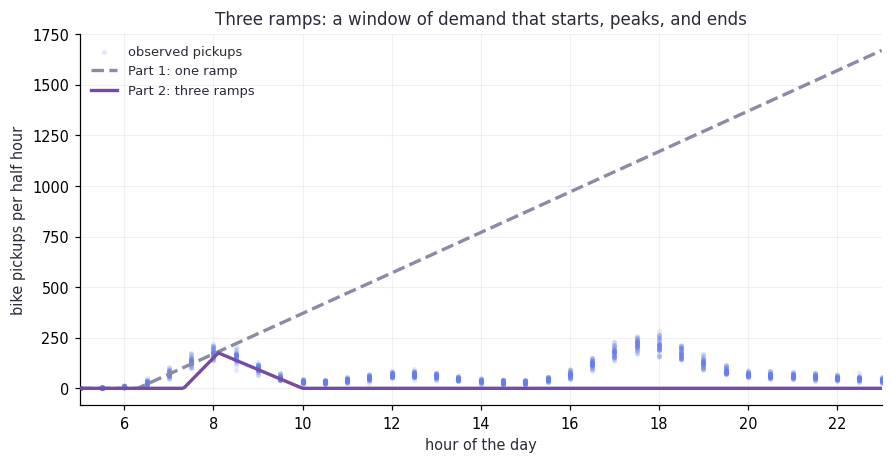

In [11]:
#@title 📊 Your hand-built morning rush (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_morning_rush(hourly, hour_grid, one_neuron, morning_rush)

### 🎛️ Now go and feel it

Choosing the four parameters tells you what the knobs **are**. Moving them shows you what they **do**.

The panel below starts from your solution, with the dawn baseline added underneath the morning bump. Drag the sliders and watch how the error changes.

There are three things to look for:

* **Can you get close to 14.6?** This is approximately the noise floor for the morning window. A well tuned triangle can reach about **14.8**, so there is very little room left for improvement.

* **Which parameter matters most?** Once you are close to a good solution, move each slider slightly. You will notice that changing `peaks at` affects the error much more than changing `starts at`. Some parameters matter more than others.

* **Is 175 really the best height?** Although the observed demand peaks near 175, a height closer to **157** fits better. The reason is that the dawn baseline already contributes about 34 pickups, so the bump does not need to explain the entire peak by itself.

This last point is important: the best value of one parameter depends on the values of the others. Once many neurons interact, finding those values by hand quickly becomes impractical.

Keep an eye on the nudge counter while you experiment.


In [12]:
#@title 🎛️ Turn the knobs yourself: drag the sliders, watch the error move (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_bump_tuner(hourly, start=(RUSH_HEIGHT, RUSH_START, RUSH_PEAK, RUSH_END))

### What you just did has a name

You moved a parameter, watched how the error changed, and used that information to decide what to try next. Then you repeated the process until further changes stopped helping.

That loop is the idea behind Part 3. The machine will do the same thing, with two important differences: it will **calculate** which direction reduces the error, and it will update all parameters together rather than one at a time.

And already the limitation is clear. One bump required four parameters and several manual adjustments. Scaling that process to the whole day quickly becomes impractical.

### The whole day, by hand

The full demand curve contains four main structures: the morning rush, the lunch lift, the evening rush and the evening drift, plus a baseline that rises at dawn and then stays roughly constant.

Each bump requires **three ramps**: one to start the rise, one to turn the rise into a fall, and one to stop the fall. With four bumps, that gives

$$
4 \times 3 = 12 \text{ neurons}.
$$

The dawn baseline needs **two more ramps**: one to make it rise and one to cancel that slope once the desired level is reached. So the full model uses

$$
12 + 2 = 14 \text{ neurons}.
$$

The parameter count comes from the more intuitive quantities we choose by hand. Each bump is described by four numbers, `start`, `peak`, `end` and `height`, so four bumps require

$$
4 \times 4 = 16 \text{ numbers}.
$$

The baseline needs three more values to describe where it starts, where it levels off and how high it is. That gives

$$
16 + 3 = 19 \text{ numbers}.
$$

So the complete hand built model has **fourteen neurons and nineteen parameters**, all chosen by looking directly at the scatter plot. Nothing is trained yet. The cell below simply turns those nineteen human readable choices into the ramps that make up the full curve.


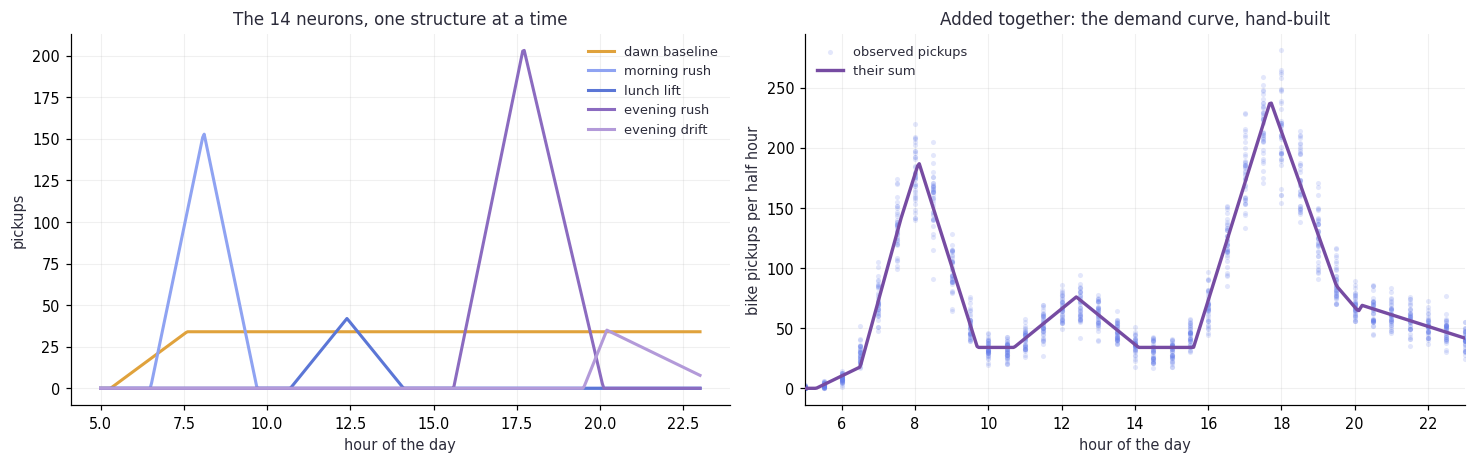

structure         height  starts   peaks    ends   ramps
────────────────────────────────────────────────────────
dawn baseline       34.0    5.30    7.60       -       2
morning rush       154.0    6.50    8.10    9.70       3
lunch lift          42.0   10.70   12.40   14.10       3
evening rush       205.0   15.60   17.70   20.10       3
evening drift       35.0   19.50   20.20   23.80       3
────────────────────────────────────────────────────────
Numbers turned by hand : 19   (ramps used: 14)
Distance from the true average demand curve : 3.61 pickups


In [13]:
#@title 🧩 The whole demand curve, hand-built from fourteen neurons (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_hand_built_day(hourly, hour_grid)

### Reading the result

With just **nineteen numbers chosen by eye**, the model follows the true average demand across the day with an error of only about **3.6 pickups**. This is small compared with peaks of 175 and 221 pickups, and even smaller than the measurement noise of roughly 14. Nothing has been trained yet. There is no optimiser and no calculus, only simple ramps placed and combined by hand.

The main limitation appears at the peaks. The real demand curve is smooth, while our approximation is made from straight line segments, so each rush ends in a sharp corner. Adding more ramps would make those corners progressively smoother and improve the fit. More neurons therefore buy us more flexibility and, potentially, greater accuracy.

At this point you have built a **universal approximator by hand**. The idea is simple: each neuron contributes a small piece of the final shape, and enough of these pieces can be combined to approximate a much more complicated function.

So the key question is no longer whether a neural network can represent the demand curve. We have just seen that it can. The real challenge is how to find the right positions, slopes and weights automatically instead of choosing them by eye.

That is where training begins. Before getting there, however, it is worth stating the universal approximation result more precisely, and understanding what it does and does not guarantee.


## The universal approximation theorem

The result we have just built by hand has a formal name: the **universal approximation theorem**.

In the language of this notebook, it says that a network with one hidden layer can approximate a continuous demand curve as closely as we want, provided we use enough neurons.

$$
\text{demand}(h)
\approx
\sum_{j=1}^{n}
v_j\,\text{ReLU}(w_jh+b_j).
$$

The individual neurons are simple ramps. The flexibility comes from adding many of them together with different positions, slopes and output weights.

### What it promises

For any **continuous function** on a **closed interval**, and for any accuracy level we choose, there exists a one hidden layer network that approximates that function within the required error.

So, over a fixed range such as the hours from 05:00 to 23:00,

$$
\text{enough neurons}
\quad\Longrightarrow\quad
\text{arbitrarily accurate approximation}.
$$

### What “enough” does not tell us

The theorem does **not** say how many neurons are required.

For one problem, a small network may be enough. For another, the number may be much larger. Greater accuracy generally requires more capacity, and more capacity means more parameters to estimate.

### Where the guarantee stops

The theorem applies to the range on which we are approximating the function. It does not promise sensible behaviour outside that range.

It also assumes the target function is continuous. The theorem is therefore a statement about **representation**, not a guarantee that every possible forecasting problem is easy.

### What it says about training

Most importantly, the theorem says that a good set of parameters **exists**.

It does not tell us what those parameters are, and it does not guarantee that an optimisation algorithm such as gradient descent will find them.

That gives us an important distinction:

$$
\text{Can the network represent the function?}
\neq
\text{Can we successfully train it?}
$$

Universal approximation answers the first question.

The rest of the notebook is largely about the second.


## Part 3. Letting the machine turn the knobs

Hand tuning worked well for one dock and one type of day. But VeloZüri has **380 docks**, each with different weekday, Saturday and holiday patterns, and those patterns also change with the seasons. That quickly becomes thousands of curves, so choosing parameters by eye is no longer realistic.

The machine follows the same loop you used manually. First, it measures how wrong the current prediction is using mean squared error:

$$
\text{MSE}
=
\frac{1}{N}
\sum_{i=1}^{N}
\bigl(y_i-f(h_i)\bigr)^2.
$$

Here, $y_i$ is the observed pickup count, $f(h_i)$ is the network prediction, and $N$ is the number of observations. Because the errors are squared, large mistakes count much more than small ones. An error of 40 contributes sixteen times as much as an error of 10.

Next, the model needs to know how to change the parameters. In the slider panel, you found the right direction by trial: move a parameter, see whether the error improves, and move it back if it does not. **Backpropagation** does this analytically, calculating how every parameter affects the error at once. The optimiser then moves all the parameters slightly in the direction that reduces the error.

One complete pass through the training data is called an **epoch**. Within each epoch, the observations are processed in small random batches. The full training loop is therefore

$$
\text{measure error}
\;\longrightarrow\;
\text{find a direction}
\;\longrightarrow\;
\text{update the parameters}
\;\longrightarrow\;
\text{repeat}.
$$

All of this is implemented in `TinyMLP` using NumPy. Setting `hidden=(n,)` gives the model one hidden layer with $n$ neurons.

### The decision that matters

The main choice we care about is **how many neurons to use**. More neurons give the network more flexibility, but they also increase the number of parameters, the computation required and the amount of data needed to estimate those parameters reliably.

So the question is not simply whether a larger network fits the training data better. The real question is whether that improvement carries over to data the network has never seen. To test this, we hold back the final ten days of observations, train the model without them, and then measure its error on those unseen days.

Training error tells us how well the model fits data it already knows. Validation error tells us how well it **generalises**. That is the number we care about when deciding how much model complexity is actually worth using.


In [14]:
#@title 🔀 Splitting the log into training days and held-out days (drawn by universal_approximation_ui.py) { display-mode: "form" }
train_hour, train_pickups, holdout_hour, holdout_pickups, NOISE_FLOOR = split_days(hourly)

Training on  : days  1–30  (1,110 counts)
Held out     : days 31–40  (370 counts)

Noise floor  : 13.6 pickups, what a *perfect* forecast still gets wrong
               on the held-out days. Anything close to it is as good as this problem gets.


### 🎯 Exercise 3. Train networks of different sizes

**Task.** Train one network for each width in `WIDTHS`, using a single hidden layer, and store the trained models in the `models` dictionary using the width as the key.

Use

```python
TinyMLP(hidden=(width,), activation='relu', seed=RANDOM_STATE)
```

and train each model with

```python
.fit(train_hour, train_pickups, epochs=6000, lr=0.02, batch_size=128)
```

Choose widths that cover a broad range, roughly doubling each time. The goal is to see how much the held out error improves as the network gets wider, and where adding more neurons stops making a meaningful difference.

A useful range goes from **1 neuron to a few dozen neurons**.

<details>

<summary>💡 <b>Hint 1</b></summary>

A doubling sequence makes it easy to compare small and large networks without testing too many sizes.

For example:

```python
WIDTHS = (1, 2, 4, 8, 16, 32)
```

</details>

<details>

<summary>🔧 <b>Hint 2</b></summary>

Create an empty dictionary, then loop over the widths:

```python
models = {}

for width in WIDTHS:
    ...
```

Each trained model should be stored as

```python
models[width] = ...
```

</details>

<details>

<summary>📏 <b>Hint 3</b></summary>

For each width, create and fit the model in one step:

```python
models[width] = TinyMLP(
    hidden=(width,),
    activation='relu',
    seed=RANDOM_STATE
).fit(
    train_hour,
    train_pickups,
    epochs=6000,
    lr=0.02,
    batch_size=128
)
```

Once trained, compare the models using their error on the held out data, not on the training data.

</details>


In [15]:
# 🎯 YOUR TURN, Exercise 3: how many neurons does this curve actually need?
#
# 💭 Think first: in Part 2 you built this curve out of a dawn shelf and four bumps,
#    fourteen ramps in all. So roughly how many neurons should a trained network need
#    before it can represent the whole day? Write your guess down, because the chart
#    two cells below will either confirm it or embarrass it.
#
# 🎯 Implement: pick a range of widths that roughly doubles each time (start at 1, and
#    go somewhere past 30), then train one network per width and store it in `models`
#    under that width:
#       TinyMLP(hidden=(width,), activation='relu', seed=RANDOM_STATE)
#           .fit(train_hour, train_pickups, epochs=6000, lr=0.02, batch_size=128)

WIDTHS = (1, 2, 4, 8, 16, 32)

models = {}
for width in WIDTHS:
    models[width] = TinyMLP(
        hidden=(width,),
        activation='relu',
        seed=RANDOM_STATE
    ).fit(
        train_hour,
        train_pickups,
        epochs=6000,
        lr=0.02,
        batch_size=128
    )
    print(f'{width:3d} neurons ({models[width].n_parameters:3d} numbers to learn) → '
          f'held-out error {rmse(holdout_pickups, models[width].predict(holdout_hour)):5.1f} pickups')

  1 neurons (  4 numbers to learn) → held-out error  59.1 pickups
  2 neurons (  7 numbers to learn) → held-out error  58.0 pickups
  4 neurons ( 13 numbers to learn) → held-out error  50.5 pickups
  8 neurons ( 25 numbers to learn) → held-out error  24.1 pickups
 16 neurons ( 49 numbers to learn) → held-out error  15.4 pickups
 32 neurons ( 97 numbers to learn) → held-out error  16.2 pickups


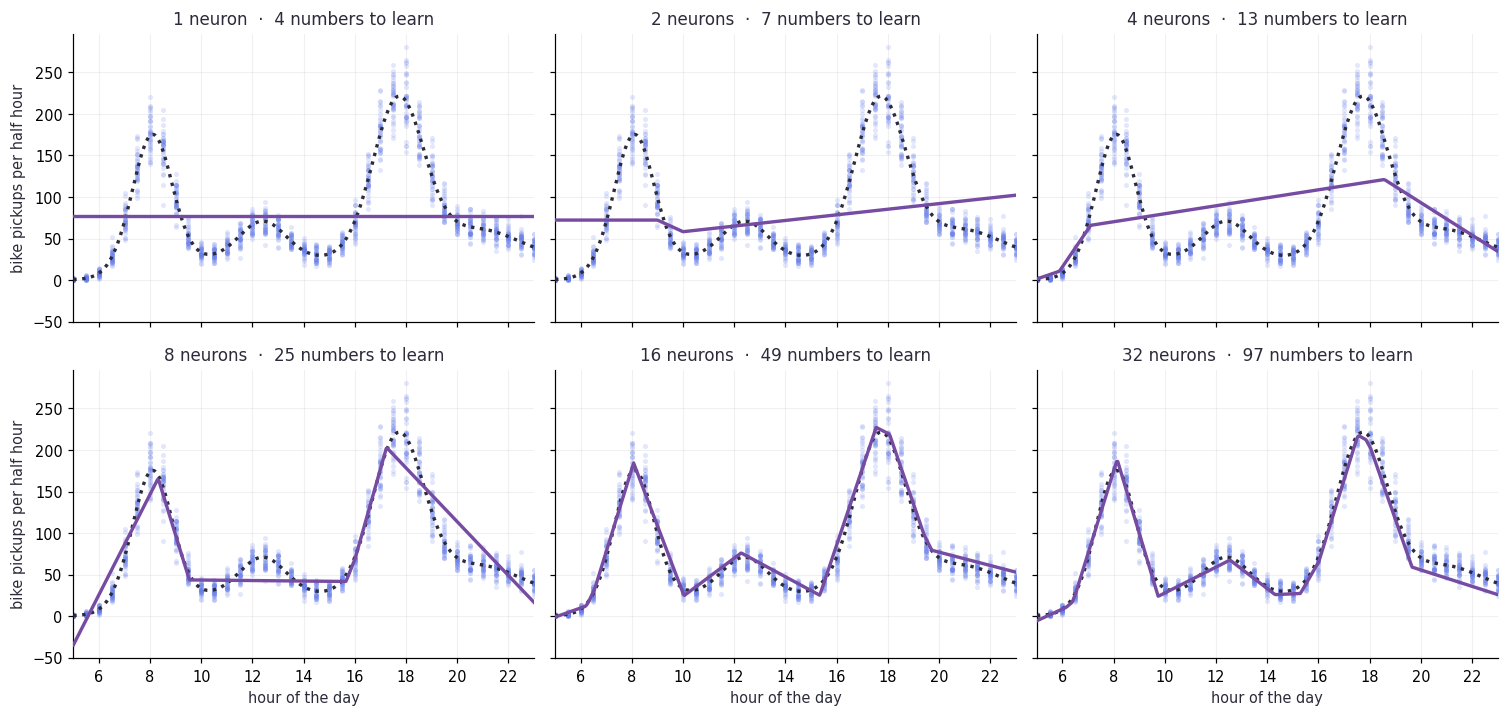

In [16]:
#@title 📊 The same curve, at every budget you tried (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_width_sweep(hourly, models)

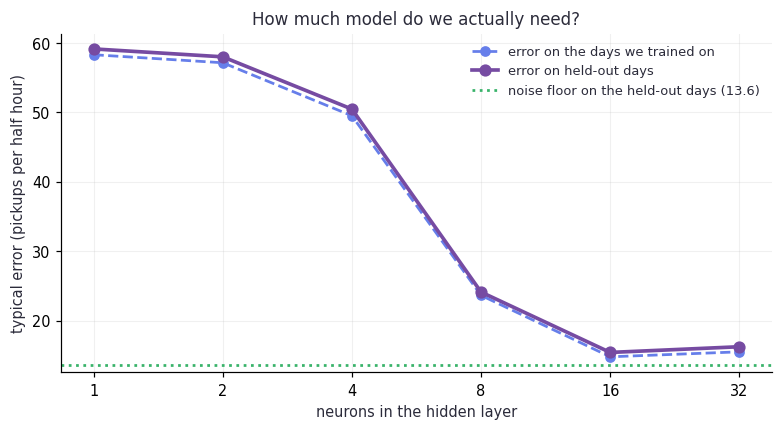

Best held-out error of any size : 15.41 pickups
Cheapest network within 2% of it: 16 neurons, 49 numbers to learn.


In [17]:
#@title 📊 Error against model size, and the cheapest network at the elbow (drawn by universal_approximation_ui.py) { display-mode: "form" }
best, best_net = show_model_size_tradeoff(
    models, train_hour, train_pickups, holdout_hour, holdout_pickups, NOISE_FLOOR)

### Reading the result

The error curve has a simple shape: a steep drop followed by a plateau.

With one or two neurons, the network is too small to represent the daily pattern. Four neurons produce only a rough approximation, with an error of about 50 pickups. Eight neurons reduce that to around 24. At **sixteen neurons**, the held out error falls to about **15.4 pickups**, very close to the estimated noise floor of **13.6**.

That is also consistent with what we built by hand in Part 2. The manual construction used fourteen ramps, while the trained network reaches essentially the same level of accuracy with sixteen neurons.

After that, adding capacity no longer helps. A network with thirty two neurons gives an error of about **16.2 pickups**, slightly worse than the sixteen neuron model. Once performance is already close to the noise floor, the remaining variation comes largely from effects that the model cannot predict from the hour alone. More neurons therefore add cost without buying useful accuracy.

The training error is slightly lower than the held out error at every width. The gap is small, so there is no dramatic overfitting here, but the direction is important: evaluating a model on the same data used to fit it always gives an optimistic picture. For model selection, the held out error is the one that matters.

This gives a practical interpretation of universal approximation. The theorem tells us that enough neurons can approximate the function, but it does not tell us how many are enough. In practice, we train networks of increasing size, compare their performance on unseen data, and stop when additional capacity stops producing a meaningful improvement.

For Nadia, the conclusion is straightforward: about **sixteen neurons** are enough for this curve. The model can forecast demand to within roughly **15 pickups per half hour**, and increasing the network size beyond that is unlikely to improve the forecast in a meaningful way.


## Part 4. The whole city: the same idea in two dimensions

The next question is no longer **when** demand appears, but **where** it concentrates across the city.

The site survey gives us 700 measured locations, each with a pickup count. What Nadia needs, however, is a complete demand surface: an estimate at every point in the city, including locations that were never surveyed.

The basic idea does not change. The network still adds together simple ReLU pieces, but each neuron now receives two inputs instead of one:

$$
f(x,y)
=
\sum_j
v_j\max\bigl(0,\;w_{j,x}x+w_{j,y}y+b_j\bigr),
$$

where $x$ and $y$ represent position in kilometres east and north of the Hauptbahnhof.

In one dimension, a ReLU neuron created a ramp: flat on one side of a point, then rising in a straight line. In two dimensions, the same neuron is flat on one side of a **line** across the map and becomes a tilted plane on the other. The line acts like a crease. Combining many neurons therefore produces a surface made from flat facets joined along different creases.

The problem is more demanding than the daily curve. In one dimension, three ramps were enough to isolate a local bump. On a map, creating a local region requires several boundaries around it, and the city contains multiple neighbourhoods together with broader spatial trends. For this reason we use a **second hidden layer**. The first layer creates simple spatial boundaries, while the second combines them into more complex regions. We will use two hidden layers with 48 neurons each.

### The real budget is the data

There is also a different practical constraint in this problem. Increasing the size of the network is relatively cheap. Collecting more observations is not.

Every additional survey location requires time and money, so the important question is no longer simply how many neurons the model should have. It is **how many surveyed sites are needed before the estimated demand map becomes reliable enough to guide a real decision**.

That is the tradeoff we will study next.


In [20]:
# The 10,000 map points we will ask the model about, and the census folded back into a
# map so we can grade the answer against it.
map_coords = city_map_grid()
truth_grid = as_map(truth['demand'])

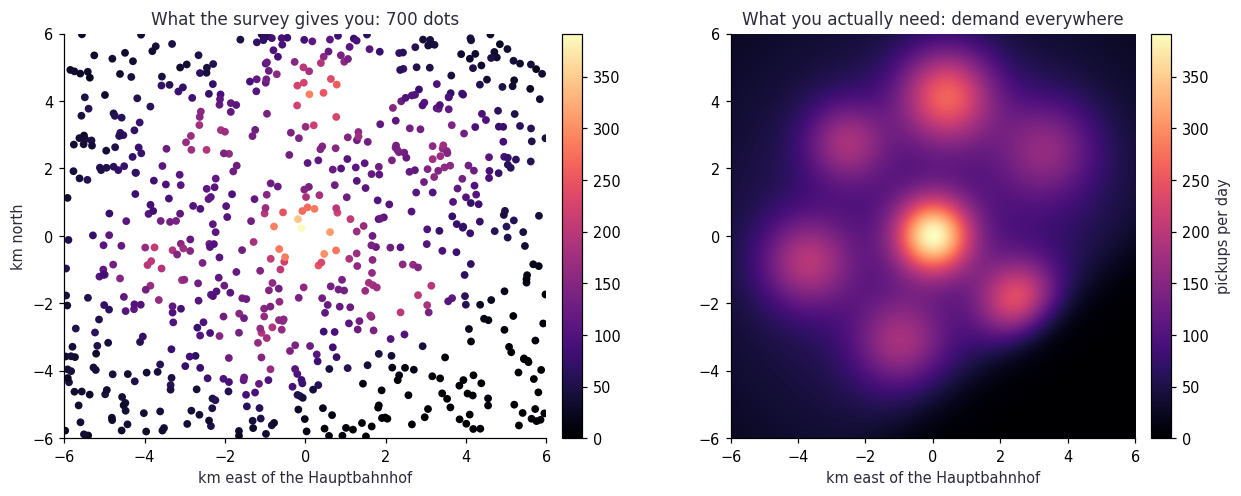

The right-hand map is a full census of the city. VeloZüri does not have it and
never will. It is here only so we can grade the model honestly. The model will
only ever see the dots on the left.


In [19]:
#@title 📊 What we surveyed, and what we wish we had (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_survey_and_census(stations, truth_grid)

### 🎯 Exercise 4. Turn 700 dots into a map

**Task.** Train a network that predicts daily pickups from a location on the map. Use only the first `SURVEY_BUDGET` surveyed sites and store the fitted model in `city_net`.

Start with all **700 sites**. In the next step, we will reduce the survey budget and see how much accuracy we lose.

Use a network with two hidden layers:

```python
TinyMLP(hidden=(48, 48), activation='relu', seed=RANDOM_STATE)
```

The inputs are the two spatial coordinates, `x_km` and `y_km`, and the target is `pickups_per_day`. Fit the model for 4000 epochs with a learning rate of `0.01`.

Training takes roughly twenty seconds. While it runs, watch the printed error decrease.

<details>

<summary>💡 <b>Hint 1</b></summary>

Start by choosing how many surveyed sites to use. For the full survey,

```python
SURVEY_BUDGET = 700
```

Then keep only the first `SURVEY_BUDGET` rows.

</details>

<details>

<summary>🔧 <b>Hint 2</b></summary>

The model needs a matrix with two input columns:

```python
X_city = survey[['x_km', 'y_km']].to_numpy()
```

and one target vector:

```python
y_city = survey['pickups_per_day'].to_numpy().astype(float)
```

Remember to restrict both to the chosen survey budget.

</details>

<details>

<summary>📍 <b>Hint 3</b></summary>

Create the network and fit it on the selected sites:

```python
city_net = TinyMLP(
    hidden=(48, 48),
    activation='relu',
    seed=RANDOM_STATE
).fit(
    X_city,
    y_city,
    epochs=4000,
    lr=0.01,
    verbose=True
)
```

</details>


In [ ]:
# 🎯 YOUR TURN, Exercise 4: reconstruct the demand map from the site survey.
#
# 💭 Think first: the network will be asked for a demand figure at every point of a
#    12 km × 12 km city, having been told the answer at a few hundred scattered dots.
#    Where on the map do you expect it to be trustworthy, and where do you expect it to
#    be making things up? Look at the left-hand scatter above before you answer.
#
# 🎯 Implement: take the first SURVEY_BUDGET rows of `stations` as `survey`, then fit a
#    two-hidden-layer network on the x/y columns:
#       TinyMLP(hidden=(48, 48), activation='relu', seed=RANDOM_STATE)
#           .fit(survey[['x_km', 'y_km']].to_numpy(),
#                survey['pickups_per_day'].to_numpy().astype(float),
#                epochs=4000, lr=0.01, verbose=True)
#    Store it in `city_net`. Start with the full budget of 700 sites.

SURVEY_BUDGET = 700
survey = ...

city_net = ...

predicted_grid = as_map(city_net.predict(map_coords))
print(f'\n{city_net.n_parameters:,} numbers learned from {SURVEY_BUDGET} surveyed sites.')
print(f'Error against the full census: {rmse(truth_grid, predicted_grid):.1f} pickups per day.')

In [ ]:
#@title 📊 The reconstructed city (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_reconstructed_city(truth_grid, predicted_grid, SURVEY_BUDGET)

The network recovers the main spatial structure of the city from only a few hundred scattered observations: the seven neighbourhood hotspots, the gradual decrease in demand towards the outskirts, and the low demand region in the south east where the Zürichsee lies.

The third panel uses the same colour scale as the first two. That is why it appears almost entirely dark: the prediction error is small compared with the scale of the demand itself.

The lake is especially interesting. Learning a hotspot means discovering where demand is high. Learning a **hole** means discovering where demand consistently disappears. The network was never told where the shoreline is. It inferred that structure only from the surveyed locations with very low or zero pickup counts.

### How many sites should you have paid for?

The network itself is cheap to train. The expensive part is collecting the survey data.

So now we can ask the more practical question: how many sites were actually necessary?

We will train the same network in the same way using only the first **40, 150 and 700 surveyed sites**, then compare the resulting maps and errors. This lets us see how much additional survey coverage improves the final demand surface.


In [ ]:
#@title 📊 The same model on three survey budgets (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_budget_comparison(stations, truth_grid, map_coords)

### Reading the result

The three survey budgets lead to very different maps.

With **40 sites**, the network has far too little information to recover the true spatial structure. It fills the unsurveyed areas with sharp facets and ridges determined mostly by where those few observations happen to lie. The result is not simply a rougher version of the true map: some of the structure is wrong. The error is about **32 pickups per day**, two of the three proposed depot locations are misplaced, and Oerlikon is missed entirely. Importantly, the model does not indicate that it is uncertain. It simply produces a complete surface.

With **150 sites**, the main hotspots begin to appear and the proposed depots fall in the correct neighbourhoods. The map is still imperfect, though. The depot locations are somewhat displaced, the ranking of the second and third hotspots is reversed, the shoreline is less clearly recovered, and some artificial structure remains. The error falls to about **18 pickups per day**.

With **700 sites**, the picture changes substantially. The error drops to about **8 pickups per day**, the main hotspots are correctly located and ranked, and the low demand region around the lake is recovered much more accurately. This is the first map that is reliable enough to support the depot decision.

### What this means for the depot decision

The limiting factor was not the network's capacity. The same model was used in all three cases. What changed was the amount of information available to constrain it.

The universal approximation theorem tells us that the network is flexible enough to represent the true demand surface. It does not tell us that the correct surface can be recovered from a small number of observations. With too few sites, many very different maps are compatible with the data.

The practical lesson is therefore simple: **model capacity is cheap, but spatial coverage is not**. For this problem, collecting enough observations matters more than making the network larger.


## Part 5. Where universal approximation stops helping

There is one phrase in the universal approximation theorem that matters more than it first appears: the guarantee applies to a continuous function **on a closed and bounded region**.

Everything we have done so far stayed inside the region covered by the data. The dock model was trained on observations between 05:00 and 23:00, and we evaluated it over the same range. The city survey covered a 12 × 12 km area, and we predicted demand inside that area.

Within the observed range, the network can learn an increasingly accurate approximation. Outside that range, the theorem gives us no guarantee at all.

This distinction matters in practice because a trained model can still produce a prediction for inputs it has never seen. Nothing prevents us from asking the dock model about 03:00, even though no observations from that time were used during training. The model will return a number, but that does not mean the number is meaningful.

### 🎯 Exercise 5. Ask the model about the night shift

**Task.** Take `best_net`, the network selected in Part 3, and ask it to predict demand during the hours outside its training range.

Create predictions for midnight, 01:00, 02:00, 03:00 and 04:00, and store them in `night_forecast`.

These hours are particularly relevant because they are when the rebalancing vans may actually operate, but the model has never seen demand observations there.

Before reading on, look at the predictions carefully. The important question is not whether the model returns an answer. It will.

The question is whether we have any reason to trust it.

<details>

<summary>💡 <b>Hint 1</b></summary>

Create a NumPy array containing the five hours you want to test:

```python
NIGHT_HOURS = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
```

</details>

<details>

<summary>🔧 <b>Hint 2</b></summary>

`best_net` is already trained, so there is no need to fit it again. Pass the new hours directly to `predict`:

```python
night_forecast = best_net.predict(NIGHT_HOURS)
```

</details>


In [ ]:
# 🎯 YOUR TURN, Exercise 5: what does our best model say about the night shift?
#
# 💭 Think first: the model has never seen a single observation before 05:00. It has no
#    concept of "night", nothing in it flags an hour as out of range, and everything it
#    draws is straight lines. So what will it answer for 02:00: a sensible small number,
#    a refusal, or something else? Commit to a guess before you run the cell.
#
# 🎯 Implement: ask `best_net` (the network Part 3 settled on) for the five hours
#    the rebalancing vans operate, midnight through 04:00, using `.predict(...)`, and
#    store the answers in `night_forecast`.

NIGHT_HOURS = ...
night_forecast = ...

for hour, prediction in zip(NIGHT_HOURS, night_forecast):
    print(f'  {int(hour):02d}:00  →  {prediction:7.1f} pickups')

In [ ]:
#@title 📊 The model outside the hours it was shown (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_extrapolation(hourly, best_net, best, NIGHT_HOURS, night_forecast)

### Reading the result

Every hour in the night shift comes back **negative**. The reason is simple: a ReLU network extrapolates using the straight line it has learned at the edge of the training range. Once the data stop at 23:00, the model simply keeps extending that final segment.

In this case, the prediction continues downward by roughly eleven pickups per hour. That failure is easy to notice because negative demand is obviously impossible.

The more dangerous case is when the extrapolation still looks plausible. The model does not know that the clock wraps around after 23:00. To it, hour 24 is just a number larger than 23. If we encode midnight as 24 rather than 0, the network may return perfectly reasonable looking values such as **44 pickups at midnight** and **26 at 02:00**.

Those numbers look harmless, but they are supported by no observations at all. The model has never seen demand outside the 05:00 to 23:00 range. It is not estimating what happens at night. It is simply continuing the last linear piece beyond the region where it was trained.

This is the key lesson: **a plausible prediction is not the same as a supported prediction**. Outside the training range, the network will still return an answer, but universal approximation gives us no reason to trust it.

If you trained a different network width in Part 3, the final linear segment would be different and so would the night predictions. The next step makes that dependence visible.

In [ ]:
#@title 📊 Five equally good models, asked about the night (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_seed_disagreement(
    hourly, train_hour, train_pickups, holdout_hour, holdout_pickups, best)

### Reading the result

Five networks, trained on the same data with the same architecture and the same procedure, can still behave very differently outside the range they were trained on. The only difference between them is the random initialization of their parameters.

Inside the observed hours, from 05:00 to 23:00, all five models are reasonable. Their held out errors lie between about 15 and 24 pickups, and their predictions differ by amounts comparable to the noise in the data. Any one of them could plausibly have been selected for deployment.

Outside that range, the agreement disappears. At midnight, their predictions range from about **−336 to −56 pickups**, a spread of roughly 280. Extending further into the following morning makes the disagreement even larger.

The reason is simple: there is no night time data telling the models what should happen there. Each network fits the observed hours reasonably well, but nothing in the training data determines how the learned curve should continue beyond 05:00 and 23:00. Different initializations therefore lead to different extrapolations, even when their performance inside the observed range is similar.

Three practical lessons follow.

1. **The valid input range is part of the model.** A trained network is not fully specified by its weights alone. We also need to know the range of inputs on which those weights were fitted. For this model, that means recording that it was trained on hours from **05:00 to 23:00**.

2. **Out of range predictions can look perfectly reasonable.** The model does not produce a warning when asked about an unseen hour. It simply returns a number. Obviously impossible predictions may be noticed, but plausible ones can easily pass unnoticed.

3. **The guardrail should sit outside the network.** If the model was trained only on 05:00 to 23:00, the safest solution is to reject predictions outside that interval rather than trust the extrapolation.

The same argument applies to the city map from Part 4. A network trained inside the surveyed region will still return a prediction for a location far outside it, but that prediction is not supported by the data.

### ⭐ Bonus. One wide layer, or two narrow ones?

The universal approximation theorem tells us that a network with **one sufficiently wide hidden layer** can approximate a continuous function. So why did the city model use two hidden layers?

Because representational possibility and efficiency are different questions. A single hidden layer may be able to represent the same function, but it may require many more neurons to do so.

In the next comparison, we fit the same city demand surface in two ways: once with two hidden layers of 48 neurons, and once with a single hidden layer chosen to have approximately the same number of learned parameters. The data, parameter budget and training procedure stay the same.

The question is therefore not whether one hidden layer can represent the map. The theorem already tells us that it can. The question is whether **depth can use the same parameter budget more effectively**.

In [ ]:
#@title ⭐ Bonus: depth versus width at an identical parameter budget (drawn by universal_approximation_ui.py) { display-mode: "form" }
show_depth_vs_width(survey, truth_grid, map_coords)

### Reading the result

With the same parameter budget, the shallow network produces the weaker map. Its error is about **14 pickups per day**, compared with roughly **8** for the deeper network. The hotspots are less sharply defined, the lake boundary is less precise, and training also takes noticeably longer.

This highlights an important distinction between what a network can **represent** and what training can actually **find**. A sufficiently wide single hidden layer can represent the city surface in principle, but that does not mean gradient descent will discover the right configuration efficiently.

The deeper network uses its parameters more effectively. The first hidden layer can learn useful spatial boundaries, while the second can combine and reuse them to build more complex regions. A single very wide layer has to construct the same structure more directly.

So depth does not change the universal approximation guarantee. One hidden layer is still theoretically enough. What depth changes is how efficiently useful representations can be built and how easily training can reach them.

That is why practical neural networks are usually deep even though a single hidden layer is sufficient in theory.

## Summary

1. **A neuron is a simple ramp.** A ReLU neuron stays at zero up to a threshold, then changes linearly. Neural networks become flexible by combining many of these simple pieces.

2. **Enough ramps can approximate complex shapes.** By combining ramps into local bumps, a network can approximate a continuous function as closely as needed. More neurons mean more flexibility.

3. **Representation is not the same as training.** Universal approximation tells us that a good solution exists. It does not tell us how many neurons are needed, whether optimisation will find it, or whether the available data are sufficient.

4. **More capacity helps only up to a point.** Increase model size until validation error stops improving. Beyond that point, extra neurons add complexity without useful accuracy.

5. **Data quality and coverage set the real limit.** A powerful network cannot recover structure that is not supported by the observations. More representative data can matter more than a larger model.

6. **Predictions are trustworthy only within the supported range.** A model will still produce answers outside the region it was trained on, but those answers are extrapolations with no guarantee. The valid input range should therefore be treated as part of the model.